Task 1: This is an Image Classification problem because we are assigning a single category label (normal, scratch, dent, stain) to an entire image.

--- Dataset Summary ---
Total Images: 480
Number of Classes: 4

Class Distribution (Imbalance Check):
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


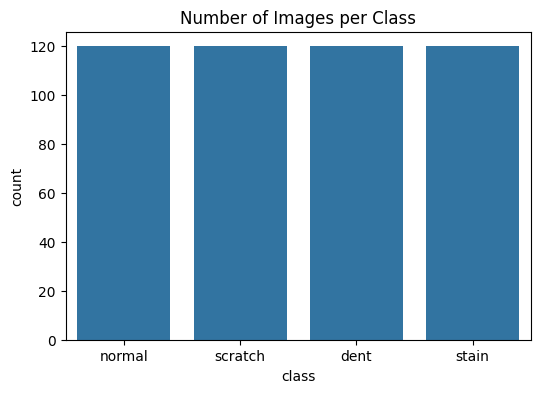

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import os

# Task 1: Problem Identification
print("Task 1: This is an Image Classification problem because we are assigning a single category label (normal, scratch, dent, stain) to an entire image.\n")

# Task 2: Dataset Exploration
df = pd.read_csv('labels.csv')

print("--- Dataset Summary ---")
print(f"Total Images: {len(df)}")
print(f"Number of Classes: {df['class'].nunique()}")
print("\nClass Distribution (Imbalance Check):")
print(df['class'].value_counts())

# Plot the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class')
plt.title('Number of Images per Class')
plt.show()


In [2]:
# Task 3: Image Preprocessing
# We use ImageDataGenerator to rescale (normalize) pixels to 0-1 and split into train/test
# Note: setting validation_split=0.2 reserves 20% of the data for testing/validation

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,     # Adding basic augmentation just in case
    horizontal_flip=True
)

# Training Data
print("Loading Training Data:")
train_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory='.',       # Looks for the paths exactly as written in labels.csv
    x_col="filename",
    y_col="class",
    subset="training",
    batch_size=32,
    seed=42,
    shuffle=True,
    class_mode="categorical",
    target_size=(128, 128) # Resizing images to a fixed size
)

# Testing/Validation Data
print("\nLoading Testing Data:")
test_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory='.',
    x_col="filename",
    y_col="class",
    subset="validation",
    batch_size=32,
    seed=42,
    shuffle=False, # Don't shuffle test data so we can map predictions to actual labels later
    class_mode="categorical",
    target_size=(128, 128)
)

Loading Training Data:
Found 384 validated image filenames belonging to 4 classes.

Loading Testing Data:
Found 96 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2839 - loss: 2.4664 - val_accuracy: 0.0000e+00 - val_loss: 1.4886
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3255 - loss: 1.3121 - val_accuracy: 0.0000e+00 - val_loss: 2.0311
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3828 - loss: 1.2625 - val_accuracy: 0.0000e+00 - val_loss: 2.3358
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4115 - loss: 1.2010 - val_accuracy: 0.0000e+00 - val_loss: 1.8709
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5703 - loss: 1.1429 - val_accuracy: 0.0000e+00 - val_loss: 3.6105
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6224 - loss: 0.9836 - val_accuracy: 0.0000e+00 - val_loss: 2.5585
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6146 - loss: 0.9135 - val_accuracy: 0.0000e+00 - val_loss: 1.5924
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6927

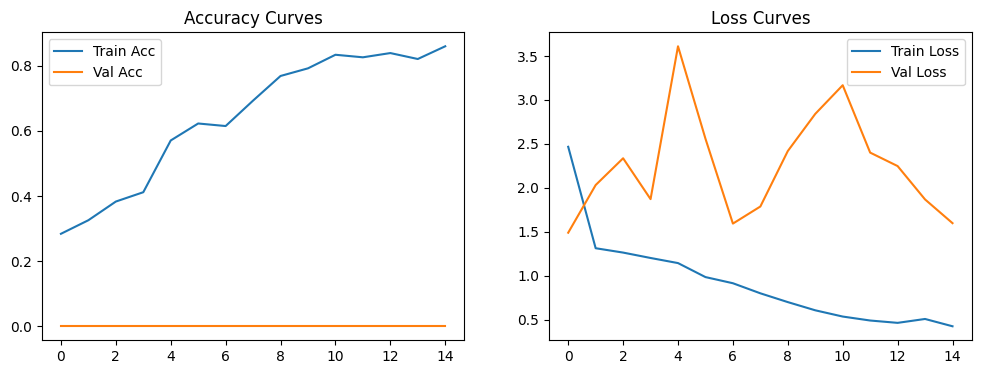

In [3]:
# Task 4: CNN Model Creation
model = Sequential([
    # Convolution layer + Activation + Pooling
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flattening layer
    Flatten(),

    # Dense layer
    Dense(128, activation='relu'),
    Dropout(0.5), # Helps prevent overfitting

    # Output layer (4 classes, so softmax activation)
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Task 5: Model Training
print("\nStarting Training...")
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

# Create results folder if it doesn't exist
os.makedirs('results', exist_ok=True)

# Plot Training & Validation Accuracy/Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Save the plot
plt.savefig('results/accuracy_loss_curves.png')
plt.show()


Evaluating Model on Test Data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.0000e+00 - loss: 1.6111
Test Accuracy: 0.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 688ms/step


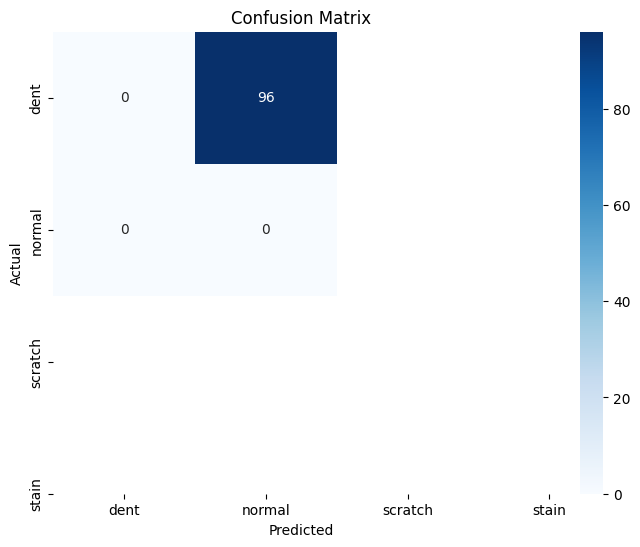

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step


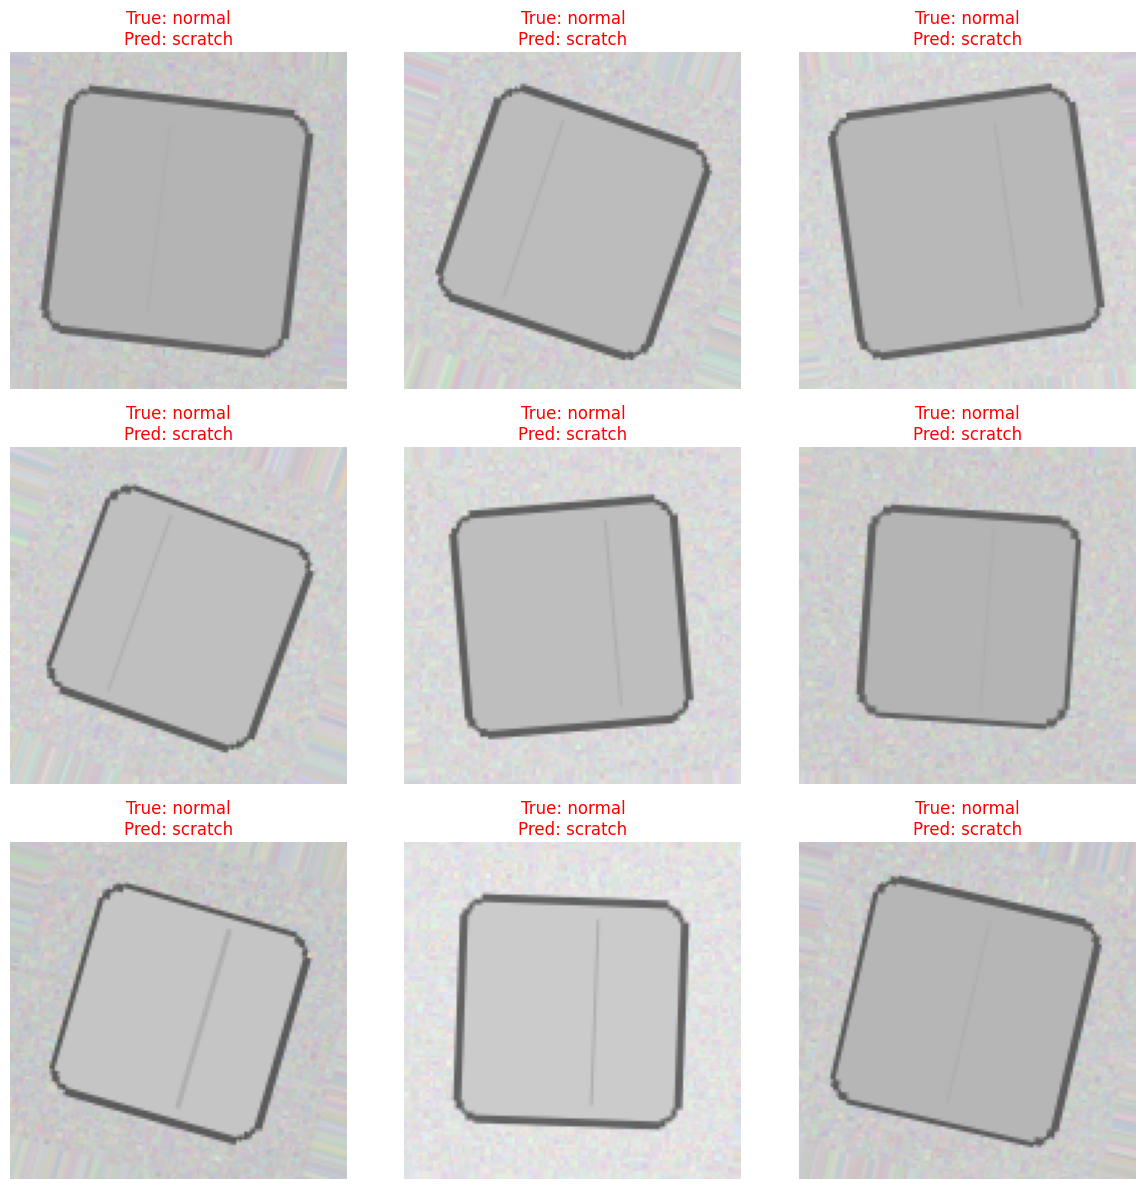

In [4]:
# Evaluate Test Performance
print("\nEvaluating Model on Test Data...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('results/confusion_matrix.png')
plt.show()

# Sample Predictions on Test Images
os.makedirs('sample_predictions', exist_ok=True)

# Grab one batch of test images
X_batch, y_batch = next(test_generator)
batch_preds = model.predict(X_batch)

plt.figure(figsize=(12, 12))
for i in range(min(9, len(X_batch))): # Show up to 9 images
    plt.subplot(3, 3, i+1)
    plt.imshow(X_batch[i])
    actual_label = class_labels[np.argmax(y_batch[i])]
    pred_label = class_labels[np.argmax(batch_preds[i])]

    color = 'green' if actual_label == pred_label else 'red'
    plt.title(f"True: {actual_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()